# Analyse Client — TheLook E-commerce 2023

Analyse exploratoire du comportement client sur l'année 2023 :
fréquence d'achat, performance par genre et délais de livraison.

**Stack :** SQL (BigQuery) · Python (Pandas, Matplotlib)  
**Dataset :** [TheLook E-commerce](https://console.cloud.google.com/marketplace/product/bigquery-public-data/thelook-ecommerce) — Google Public Data

In [11]:
#import des librairies
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

### **Fréquence d'achat**

---

### Contexte
Le directeur marketing souhaite comprendre le comportement d'achat
de ses clients : a-t-on affaire à une clientèle fidèle qui rachète
régulièrement, ou à des acheteurs ponctuels ?

### Question business
Quelle est la répartition des clients selon leur nombre de commandes
sur l'année 2023 ?

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

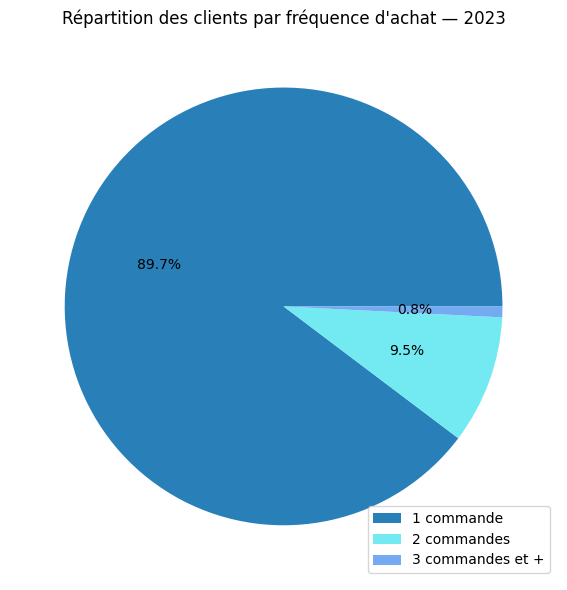

In [19]:
#Graphique fréquence d'achat
df_freq = pd.read_csv('/frequence_achat.csv')

fig, ax = plt.subplots(figsize=(8, 6))

ax.pie(
    df_freq['nb_clients'],
    autopct='%1.1f%%',
    colors=['#2980B9', '#73EAF2', '#73AAF2']
)
ax.legend(
    labels=['1 commande', '2 commandes', '3 commandes et +'],
    loc='lower right'
)
ax.set_title('Répartition des clients par fréquence d\'achat — 2023')
plt.tight_layout()
plt.savefig('frequence_achat.png', dpi=150, bbox_inches='tight')
from google.colab import files
files.download('frequence_achat.png')
plt.show()

L'analyse de la fréquence d'achat révèle un problème structurel de rétention : 90% des clients n'ont effectué qu'une seule commande sur l'année, contre 9.5% pour deux commandes et moins de 1% pour trois commandes ou plus. Ce taux de réachat de 10% est bien inférieur aux benchmarks e-commerce mode, généralement compris entre 20 et 30%.

Avant toute conclusion business, une vérification de la qualité des données s'impose — notamment s'assurer qu'un nouveau user_id n'est pas créé à chaque commande, ce qui fausserait l'analyse.

Si les données sont fiables, une analyse par rapport aux années passées permettra d'identifier si:

- la rétention s'est dégradée à un moment précis, orientant vers une cause identifiable (expérience client, qualité produit, concurrence).

- le taux de réachat a toujours été faible, le problème est structurel. Je recommande dans ce cas une analyse de satisfaction client combinée à la mise en place d'une campagne de retargeting CRM ciblant les clients à 30, 60 et 90 jours post-achat.


### **Panier Moyen par genre**

---
### Contexte
Suite à l'analyse du comportement d'achat des clients, le Directeur Marketing souhaite connaître la répartition des clients par genre.
### Question business
Qui est notre clientèle? Est ce que les femmes restent porteuse du CA en accord avec le marché du textile?

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

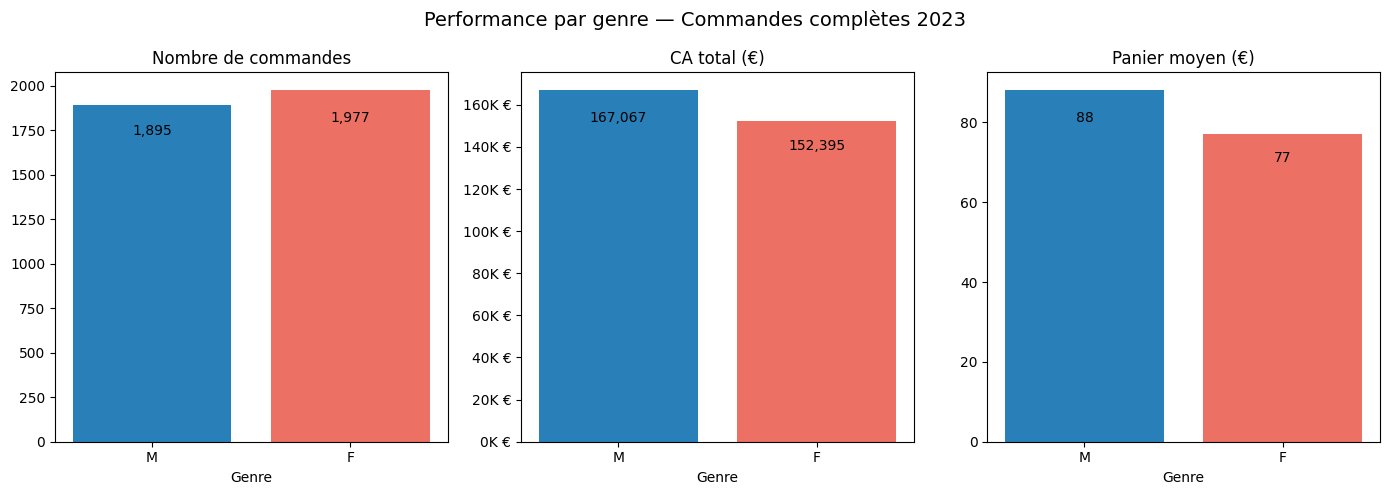

In [22]:
#panier moyen par genre
df_gender = pd.read_csv('/panier_moyen_gender.csv')

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

metriques = ['nb_commandes', 'CA', 'panier_moyen']
titres = ['Nombre de commandes', 'CA total (€)', 'Panier moyen (€)']
couleurs = ['#2980B9', '#EC7063']

for i, (metrique, titre) in enumerate(zip(metriques, titres)):
    axes[i].bar(df_gender['gender'], df_gender[metrique], color=couleurs)
    axes[i].set_title(titre)
    axes[i].set_xlabel('Genre')

    # Valeurs sur les barres
    for bar in axes[i].patches:
        axes[i].text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() * 0.90,
            f'{bar.get_height():,.0f}',
            ha='center', va='bottom', fontsize=10
        )

# Formatter l'axe Y du CA en K€
axes[1].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K €')
)

fig.suptitle('Performance par genre — Commandes complètes 2023', fontsize=14)
plt.tight_layout()
plt.savefig('panier_moyen_gender.png', dpi=150, bbox_inches='tight')
files.download('panier_moyen_gender.png')
plt.show()

La répartition du CA est quasi-iso entre hommes (52%) et femmes (48%), avec un panier moyen supérieur de 14% pour les hommes (88€ vs 77€).

Ce résultat est contre-intuitif par rapport aux benchmarks sectoriels du textile, où les femmes génèrent habituellement un CA et un panier moyen supérieurs.

Deux hypothèses méritent des analyses approfondies : un positionnement produit à dominante masculine ou une sous-performance des références féminines.

**Délai moyen de livraison**

---

### Contexte
2 analyses ont mis en avant un potentiel problème de livraison:
- une chute des commandes entre les status "Expédiée" et "Livrée" (-47%)
- une faible rétention client qui pourrait notamment s'expliquer par une insatisfaction sur l'expédition de la commande
### Question business
Quels sont les délais de livraison moyens? Est ce qu'ils peuvent expliquer ces mauvaises performances?

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

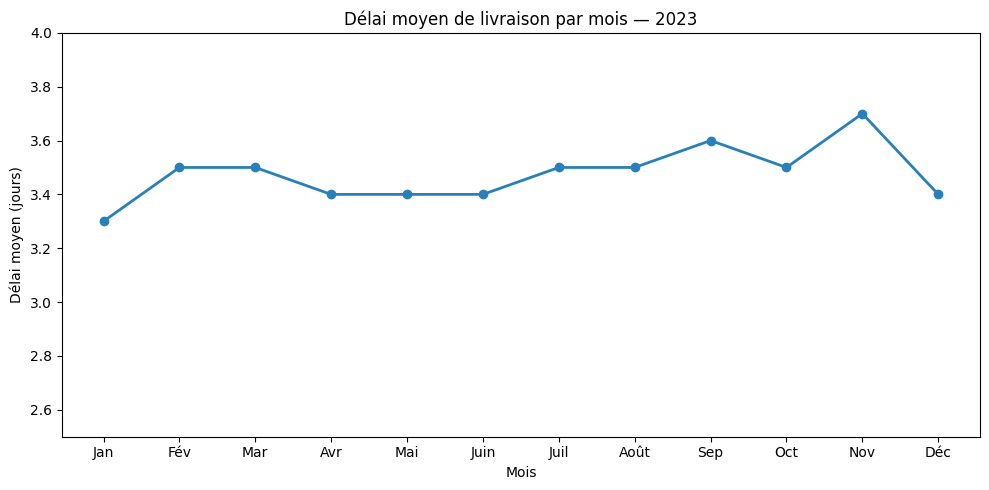

In [21]:
#délai de livraison par mois
df_delai = pd.read_csv('/delai_livraison.csv')

mois_labels = ['Jan', 'Fév', 'Mar', 'Avr', 'Mai', 'Juin',
               'Juil', 'Août', 'Sep', 'Oct', 'Nov', 'Déc']

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(df_delai['mois'], df_delai['delai_moyen_jours'],
        marker='o', color='#2980B9', linewidth=2)

ax.set_xticks(df_delai['mois'])
ax.set_xticklabels(mois_labels)
ax.set_title('Délai moyen de livraison par mois — 2023')
ax.set_xlabel('Mois')
ax.set_ylabel('Délai moyen (jours)')
ax.set_ylim(2.5, 4)


plt.tight_layout()
plt.savefig('delai_livraison.png', dpi=150, bbox_inches='tight')
files.download('delai_livraison.png')
plt.show()

Le délai moyen de livraison est de 3,5 jours, stable sur l'ensemble de l'année 2023 sans variation saisonnière notable. Ce chiffre est cohérent avec les standards du marché e-commerce (2 à 5 jours) et ne constitue pas un point d'alerte.

Deux nuances méritent cependant d'être soulevées:

1/ cette stabilité est contre-intuitive sur un vrai dataset e-commerce — les périodes Black Friday et Noël génèrent habituellement des pics de délai liés à la saturation logistique. L'absence de variation suggère soit une chaîne logistique particulièrement maîtrisée, soit un lissage artificiel des données lié à la nature fictive du dataset.

2/ ce résultat doit être mis en perspective avec l'analyse funnel précédente : si le délai de livraison est satisfaisant, la chute de -47% entre commandes expédiées et livrées reste inexpliquée.

La performance logistique sur les commandes abouties ne dit rien sur les commandes qui n'arrivent jamais à destination — ces deux questions restent distinctes et la seconde demeure prioritaire.


## Synthèse & Prochaines étapes

Les trois analyses convergent vers deux priorités :
1. **Rétention client** : 90% des clients n'achètent qu'une fois —
une campagne CRM de retargeting est recommandée en urgence.
2. **Performance logistique** : la chute de -47% entre commandes
expédiées et livrées reste inexpliquée malgré des délais satisfaisants
— un audit opérationnel s'impose.